In [1]:
import yt
import numpy as np
import matplotlib.pyplot as plt
import silmaril

In [2]:
epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

ds = yt.load('data/output_00273/info_00273.txt', extra_particle_fields = epf)
ad = ds.all_data()

yt : [INFO     ] 2025-11-17 17:43:52,356 Parameters: current_time              = 0.3604448649237178 Gyr
yt : [INFO     ] 2025-11-17 17:43:52,357 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2025-11-17 17:43:52,358 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-11-17 17:43:52,359 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-11-17 17:43:52,362 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2025-11-17 17:43:52,363 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2025-11-17 17:43:52,363 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2025-11-17 17:43:52,364 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2025-11-17 17:43:52,367 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2025-11-17 17:43:52,368 Parameters: hubble_constant           = 0.674000015258789
yt : [WARNING  ] 2025-11-17 17:43:52,540 This output

In [3]:
x = np.array(ad["star", "particle_position_x"])
y = np.array(ad["star", "particle_position_y"])
z = np.array(ad["star", "particle_position_z"])
ctr = np.array([np.mean(x), np.mean(y), np.mean(z)])
ctr

yt : [INFO     ] 2025-11-17 17:43:53,091 Identified   384/  384 intersecting domains (  385 through hilbert key indexing)


array([0.49117112, 0.49277624, 0.49474927])

In [4]:
pw = 400
sp = ds.sphere(ctr, (pw, "pc"))

yt : [INFO     ] 2025-11-17 17:43:54,281 Identified   261/  384 intersecting domains (  261 through hilbert key indexing)
yt : [INFO     ] 2025-11-17 17:43:55,592 Projection completed
yt : [INFO     ] 2025-11-17 17:43:55,594 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-11-17 17:43:55,596 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-11-17 17:43:55,598 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-11-17 17:43:55,601 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-11-17 17:43:55,606 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



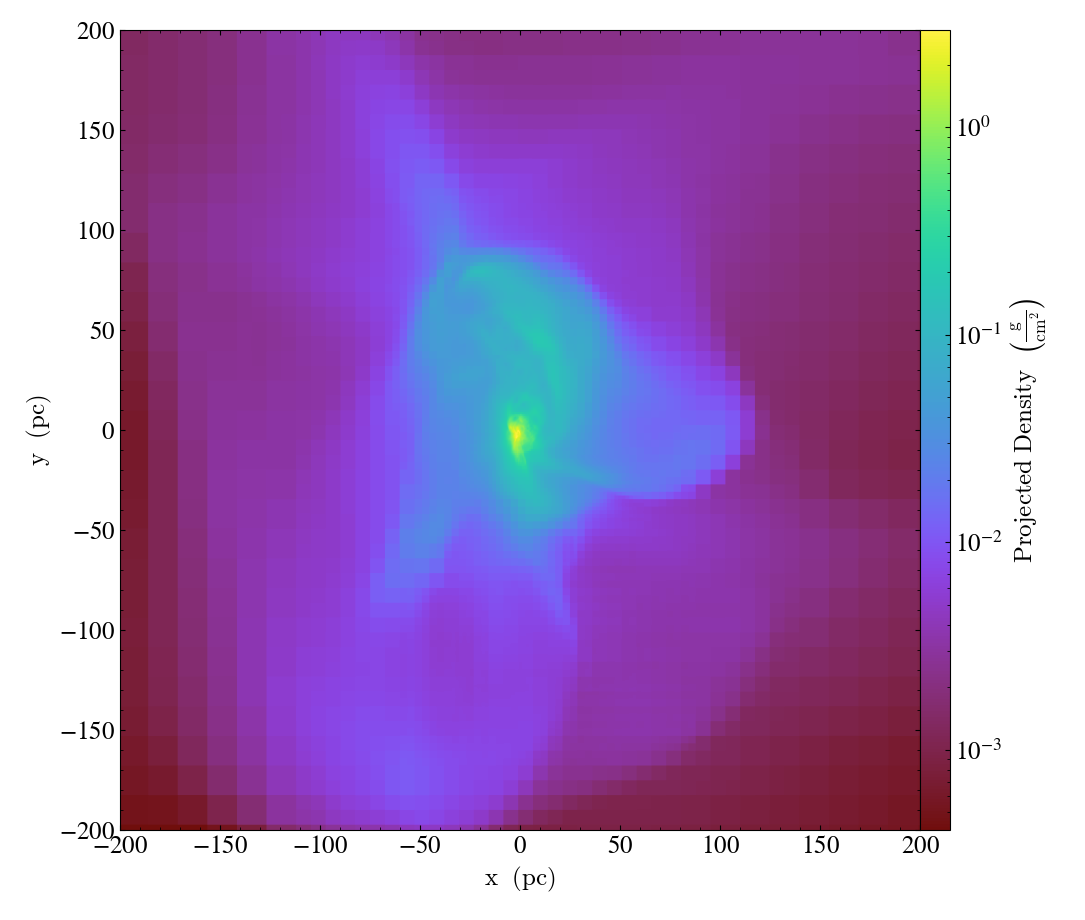

In [5]:
p1 = yt.ProjectionPlot(ds, "z", ("gas", "density"), data_source = sp, width = (pw, "pc"), center = ctr)
p1.show()

c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\yt\frontends\ramses\fields.py:241: RuntimeWarning: Trying to calculate temperature but the cooling tables couldn't be found or read. yt will return T/µ instead of T — this is equivalent to assuming µ=1.0. To suppress this, derive the temperature from temperature_over_mu with some values for mu.
  warnings.warn(
yt : [INFO     ] 2025-11-17 17:43:57,055 Projection completed
yt : [INFO     ] 2025-11-17 17:43:57,057 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-11-17 17:43:57,058 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-11-17 17:43:57,061 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-11-17 17:43:57,062 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-11-17 17:43:57,064 Making a fixed resolution buffer of (('gas', 'temperature')) 800 by 800



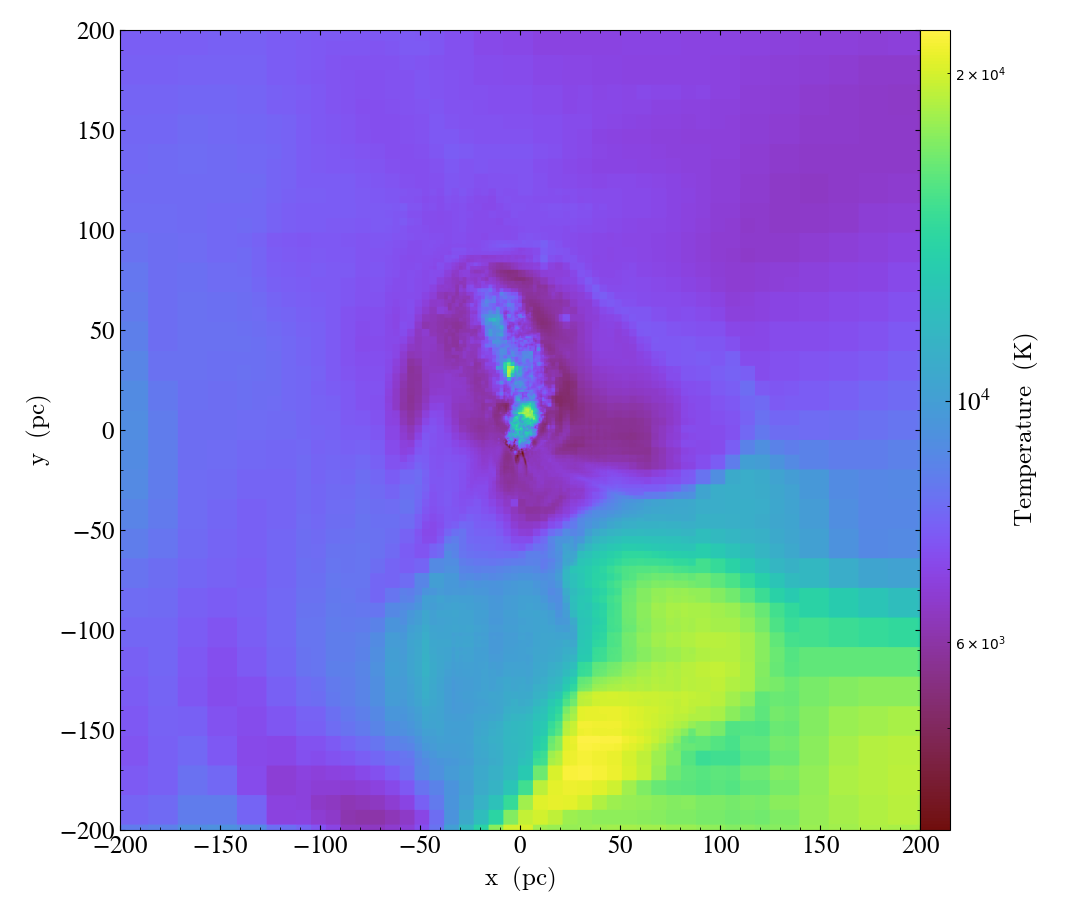

In [6]:
p2 = yt.ProjectionPlot(ds, "z", ("gas", "temperature"), weight_field = ("gas", "density"), width = (pw, "pc"), data_source = sp, center = ctr)
p2.show()

In [8]:
@yt.derived_field(name = ("star", "stellar_ages"), units = "Myr", sampling_type = "particle", force_override = True)
def _age(field, data):
    time = data.ds.current_time.in_units("Myr").value
    
    cgs_yr = 3.1556926e7  # 1yr (in s)
    cgs_pc = 3.08567758e18  # pc (in cm)
    h_0 = data.ds.hubble_constant * 100 # hubble parameter (km/s/Mpc)
    h_0_invsec = h_0 * 1e5 / (1e6 * cgs_pc)  # hubble constant h [km/s Mpc-1]->[1/sec]
    h_0inv_yr = 1 / h_0_invsec / cgs_yr  # 1/h_0 [yr]
    star_age_myr = np.array(data["star", "particle_birth_epoch"]) * h_0inv_yr / 1e6 + 13.787 * 1e3

    return data.ds.arr(time - star_age_myr, "Myr")

ds.add_field(("star", "stellar_ages"), function = _age, units = "Myr", sampling_type = "particle", force_override = True)

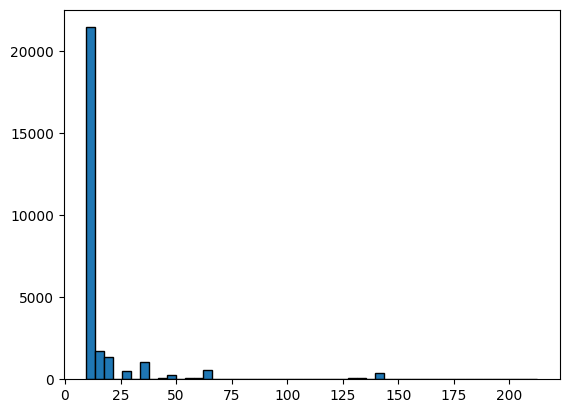

In [9]:
new_stellar_ages = np.array(ad["star", "stellar_ages"])
plt.hist(new_stellar_ages, bins = 50, edgecolor ="Black")
plt.show()

In [16]:
ad["star", "particle_index"].value

array([519., 477., 474., ..., 769., 671., 523.])

In [10]:
@yt.derived_field(name = ("star", "lum"), sampling_type = "particle", force_override = True)
def _lum(field, data):
    z = data.ds.current_redshift

    ages = np.array(data["star", "stellar_ages"])
    unique_ages = np.unique(ages)

    lum = {}
    for s in unique_ages:
        lum.update({s : silmaril.galaxy.lum_lookup_filtered(s, z, None)})

    ret = []
    for a in np.array(data["star", "stellar_ages"]):
        ret.append(lum.get(a))

    return ret

ds.add_field(("star", "lum"), function = _lum, sampling_type = "particle", force_override = True)

yt : [WARNING  ] 2025-11-17 17:44:07,498 Field ('star', 'lum') was added without specifying units or dimensions, auto setting units to 'dimensionless'


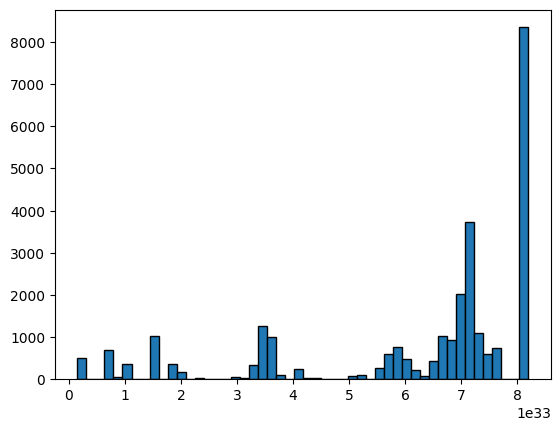

In [11]:
lums = np.array(ad["star", "lum"])
plt.hist(lums, bins = 50, edgecolor = "Black")
plt.show()

yt : [INFO     ] 2025-11-17 17:44:07,781 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-11-17 17:44:07,783 ylim = 0.492725 0.492828
yt : [INFO     ] 2025-11-17 17:44:07,788 xlim = 0.491120 0.491223
yt : [INFO     ] 2025-11-17 17:44:07,789 ylim = 0.492725 0.492828


yt : [INFO     ] 2025-11-17 17:44:07,790 Splatting (('star', 'lum')) onto a 800 by 800 mesh using method 'ngp'
yt : [INFO     ] 2025-11-17 17:44:07,879 Identified    85/  384 intersecting domains (  260 through hilbert key indexing)



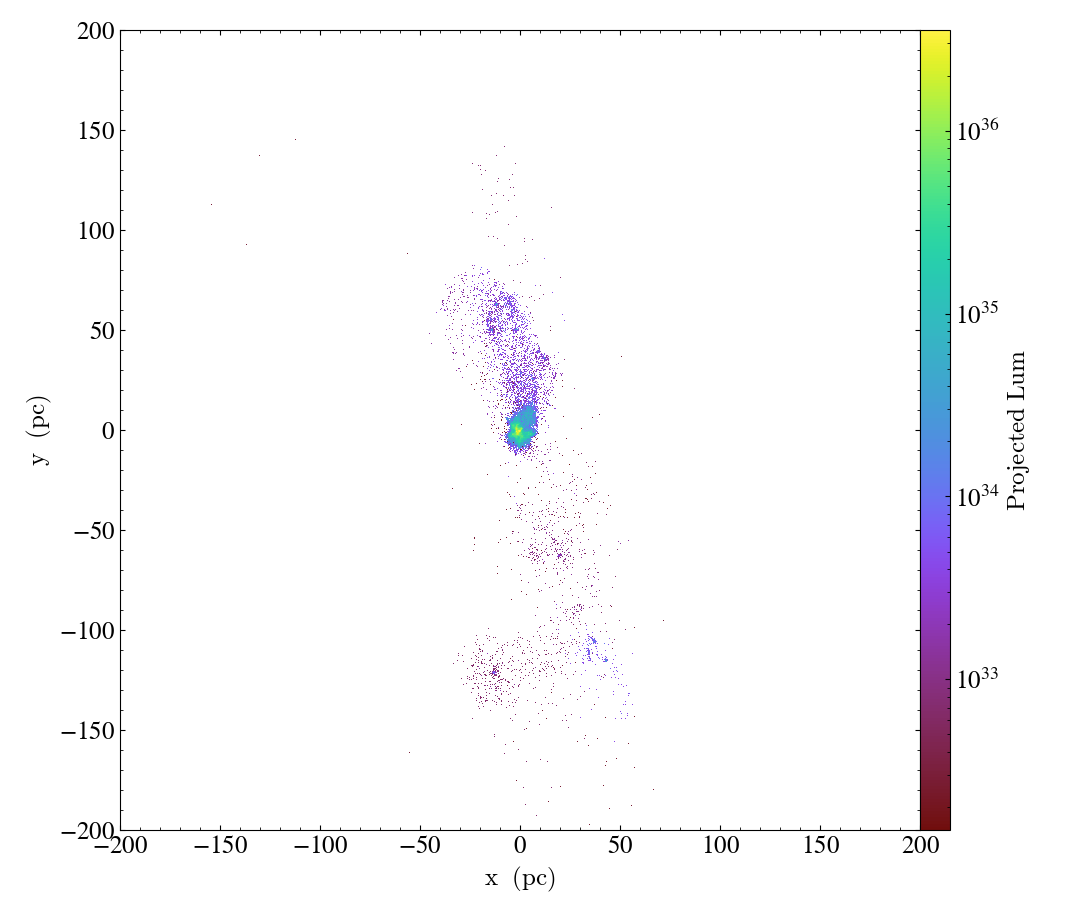

In [12]:
p3 = yt.ParticlePlot(ds, ("star", "particle_position_x"), ("star", "particle_position_y"), ("star", "lum"), data_source = sp, width = (pw, "pc"), center = ctr)
p3.show()